<a href="https://colab.research.google.com/github/Simpson69-il/DEEPLEARNING5THSEM/blob/main/ASSIGNEMENT5/Assignement3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
VOCAB_SIZE = 10000
MAX_LENGTH = 200
EMBEDDING_DIM = 128
BATCH_SIZE = 64
EPOCHS = 10

print("Vocabulary Size:", VOCAB_SIZE)
print("Maximum Sequence Length:", MAX_LENGTH)
print("Embedding Dimension:", EMBEDDING_DIM)

Vocabulary Size: 10000
Maximum Sequence Length: 200
Embedding Dimension: 128


In [3]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("First review:", X_train[0])
print("First label:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
First review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5,

In [4]:
print("Negative reviews:", np.sum(y_train == 0))
print("Positive reviews:", np.sum(y_train == 1))

Negative reviews: 12500
Positive reviews: 12500


In [5]:
word_index = imdb.get_word_index()

reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"

def decode_review(encoded_review):
    return " ".join(reverse_word_index.get(i, "?") for i in encoded_review)

print(decode_review(X_train[0]))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these c

In [6]:
X_train_pad = pad_sequences(
    X_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (25000, 200)
Testing shape: (25000, 200)


In [7]:
print("Original length:", len(X_train[0]))
print("Padded length:", len(X_train_pad[0]))

print("\nPadded sequence:")
print(X_train_pad[0])

Original length: 218
Padded length: 200

Padded sequence:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
 5244   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117 5952   15  256
    4    2    7 3766    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   98   32
 2071   56   26  141    6  194 7486   18    4  226   22   21  134  476
   26  480    5  14

In [8]:
validation_size = 5000

X_val = X_train_pad[:validation_size]
y_val = y_train[:validation_size]

X_train_final = X_train_pad[validation_size:]
y_train_final = y_train[validation_size:]

print("Training:", X_train_final.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test_pad.shape)

Training: (20000, 200)
Validation: (5000, 200)
Testing: (25000, 200)


In [9]:
def create_model(model_type):
    model = Sequential()

    model.add(
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_LENGTH
        )
    )

    if model_type == "RNN":
        model.add(SimpleRNN(128))

    elif model_type == "LSTM":
        model.add(LSTM(128))

    elif model_type == "GRU":
        model.add(GRU(128))

    model.add(Dropout(0.5))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [10]:
rnn_model = create_model("RNN")

rnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

start_time = time.time()

rnn_history = rnn_model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

rnn_training_time = time.time() - start_time

print("RNN Training Time:", round(rnn_training_time, 2), "seconds")

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 79ms/step - accuracy: 0.4987 - loss: 0.7378 - val_accuracy: 0.5092 - val_loss: 0.6936
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - accuracy: 0.5027 - loss: 0.7102 - val_accuracy: 0.4910 - val_loss: 0.7173
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 78ms/step - accuracy: 0.5452 - loss: 0.6877 - val_accuracy: 0.5216 - val_loss: 0.6921
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 81ms/step - accuracy: 0.5522 - loss: 0.6930 - val_accuracy: 0.5126 - val_loss: 0.6929
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.5720 - loss: 0.6687 - val_accuracy: 0.5102 - val_loss: 0.6978
RNN Training Time: 175.48 seconds


In [12]:
rnn_predictions_prob = rnn_model.predict(X_test_pad, verbose=0)
rnn_predictions = (rnn_predictions_prob >= 0.5).astype(int).flatten()

rnn_accuracy = accuracy_score(y_test, rnn_predictions)
rnn_precision = precision_score(y_test, rnn_predictions)
rnn_recall = recall_score(y_test, rnn_predictions)
rnn_f1 = f1_score(y_test, rnn_predictions)

print("RNN Results")
print("Accuracy :", round(rnn_accuracy, 4))
print("Precision:", round(rnn_precision, 4))
print("Recall   :", round(rnn_recall, 4))
print("F1-Score :", round(rnn_f1, 4))

RNN Results
Accuracy : 0.5148
Precision: 0.5093
Recall   : 0.8137
F1-Score : 0.6265


In [13]:
print(
    classification_report(
        y_test,
        rnn_predictions,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.54      0.22      0.31     12500
    Positive       0.51      0.81      0.63     12500

    accuracy                           0.51     25000
   macro avg       0.52      0.51      0.47     25000
weighted avg       0.52      0.51      0.47     25000



In [14]:
lstm_model = create_model("LSTM")

lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

lstm_training_time = time.time() - start_time

print("LSTM Training Time:", round(lstm_training_time, 2), "seconds")

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 316ms/step - accuracy: 0.5231 - loss: 0.6937 - val_accuracy: 0.5146 - val_loss: 0.6932
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 327ms/step - accuracy: 0.5776 - loss: 0.6605 - val_accuracy: 0.6216 - val_loss: 0.6314
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 326ms/step - accuracy: 0.6044 - loss: 0.6385 - val_accuracy: 0.5670 - val_loss: 0.6720
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 145s 334ms/step - accuracy: 0.7474 - loss: 0.5261 - val_accuracy: 0.7472 - val_loss: 0.5366
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 315ms/step - accuracy: 0.8684 - loss: 0.3350 - val_accuracy: 0.8288 - val_loss: 0.4241
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 315ms/step - accuracy: 0.9136 - loss: 0.2403 - val_accuracy: 0.8368 - val_loss: 0.4144
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 325ms/step - accuracy: 0.9422 - loss: 0.1716 - val_accuracy: 0.8396 - val_loss: 0.4533
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 327ms/step - accuracy: 0.9632 - l

In [16]:
lstm_predictions_prob = lstm_model.predict(X_test_pad, verbose=0)
lstm_predictions = (lstm_predictions_prob >= 0.5).astype(int).flatten()

lstm_accuracy = accuracy_score(y_test, lstm_predictions)
lstm_precision = precision_score(y_test, lstm_predictions)
lstm_recall = recall_score(y_test, lstm_predictions)
lstm_f1 = f1_score(y_test, lstm_predictions)

print("LSTM Results")
print("Accuracy :", round(lstm_accuracy, 4))
print("Precision:", round(lstm_precision, 4))
print("Recall   :", round(lstm_recall, 4))
print("F1-Score :", round(lstm_f1, 4))

LSTM Results
Accuracy : 0.8235
Precision: 0.8435
Recall   : 0.7943
F1-Score : 0.8182


In [17]:
print(
    classification_report(
        y_test,
        lstm_predictions,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.81      0.85      0.83     12500
    Positive       0.84      0.79      0.82     12500

    accuracy                           0.82     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.82      0.82      0.82     25000



In [18]:
gru_model = create_model("GRU")

gru_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
start_time = time.time()

gru_history = gru_model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

gru_training_time = time.time() - start_time

print("GRU Training Time:", round(gru_training_time, 2), "seconds")

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 88s 277ms/step - accuracy: 0.5120 - loss: 0.6932 - val_accuracy: 0.5268 - val_loss: 0.6905
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 274ms/step - accuracy: 0.5663 - loss: 0.6778 - val_accuracy: 0.5296 - val_loss: 0.6883
GRU Training Time: 174.08 seconds


In [20]:
gru_predictions_prob = gru_model.predict(X_test_pad, verbose=0)
gru_predictions = (gru_predictions_prob >= 0.5).astype(int).flatten()

gru_accuracy = accuracy_score(y_test, gru_predictions)
gru_precision = precision_score(y_test, gru_predictions)
gru_recall = recall_score(y_test, gru_predictions)
gru_f1 = f1_score(y_test, gru_predictions)

print("GRU Results")
print("Accuracy :", round(gru_accuracy, 4))
print("Precision:", round(gru_precision, 4))
print("Recall   :", round(gru_recall, 4))
print("F1-Score :", round(gru_f1, 4))

GRU Results
Accuracy : 0.5161
Precision: 0.5412
Recall   : 0.2113
F1-Score : 0.3039


In [21]:
print(
    classification_report(
        y_test,
        gru_predictions,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.51      0.82      0.63     12500
    Positive       0.54      0.21      0.30     12500

    accuracy                           0.52     25000
   macro avg       0.53      0.52      0.47     25000
weighted avg       0.53      0.52      0.47     25000



In [22]:
comparison = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "GRU"],
    "Accuracy": [
        rnn_accuracy,
        lstm_accuracy,
        gru_accuracy
    ],
    "Precision": [
        rnn_precision,
        lstm_precision,
        gru_precision
    ],
    "Recall": [
        rnn_recall,
        lstm_recall,
        gru_recall
    ],
    "F1-Score": [
        rnn_f1,
        lstm_f1,
        gru_f1
    ],
    "Training Time (sec)": [
        rnn_training_time,
        lstm_training_time,
        gru_training_time
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (sec)
0,Simple RNN,0.5148,0.5093,0.8137,0.6265,175.4782
1,LSTM,0.8235,0.8435,0.7943,0.8182,851.0187
2,GRU,0.5161,0.5412,0.2113,0.3039,174.0772


In [23]:
best_accuracy_model = comparison.loc[
    comparison["Accuracy"].idxmax(),
    "Model"
]

best_f1_model = comparison.loc[
    comparison["F1-Score"].idxmax(),
    "Model"
]

fastest_model = comparison.loc[
    comparison["Training Time (sec)"].idxmin(),
    "Model"
]

print("Best Accuracy Model:", best_accuracy_model)
print("Best F1-Score Model:", best_f1_model)
print("Fastest Model:", fastest_model)

Best Accuracy Model: LSTM
Best F1-Score Model: LSTM
Fastest Model: GRU


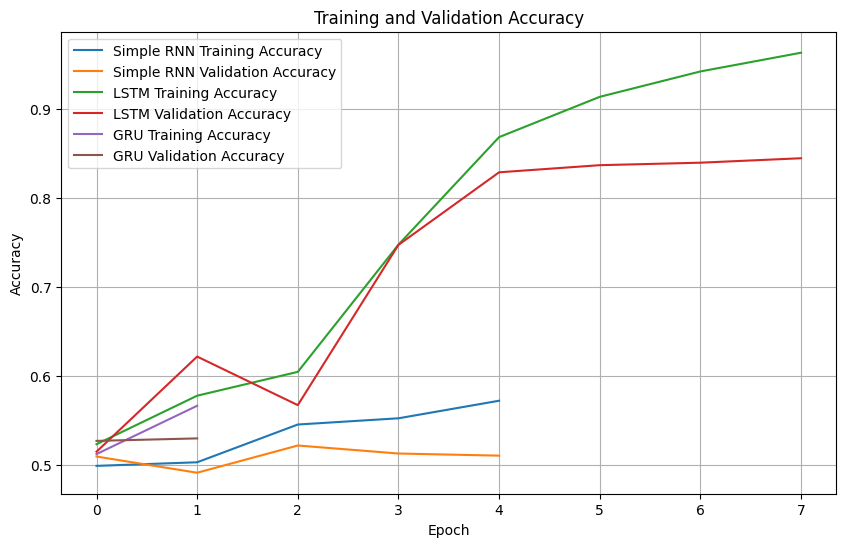

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(
    rnn_history.history["accuracy"],
    label="Simple RNN Training Accuracy"
)

plt.plot(
    rnn_history.history["val_accuracy"],
    label="Simple RNN Validation Accuracy"
)

plt.plot(
    lstm_history.history["accuracy"],
    label="LSTM Training Accuracy"
)

plt.plot(
    lstm_history.history["val_accuracy"],
    label="LSTM Validation Accuracy"
)

plt.plot(
    gru_history.history["accuracy"],
    label="GRU Training Accuracy"
)

plt.plot(
    gru_history.history["val_accuracy"],
    label="GRU Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

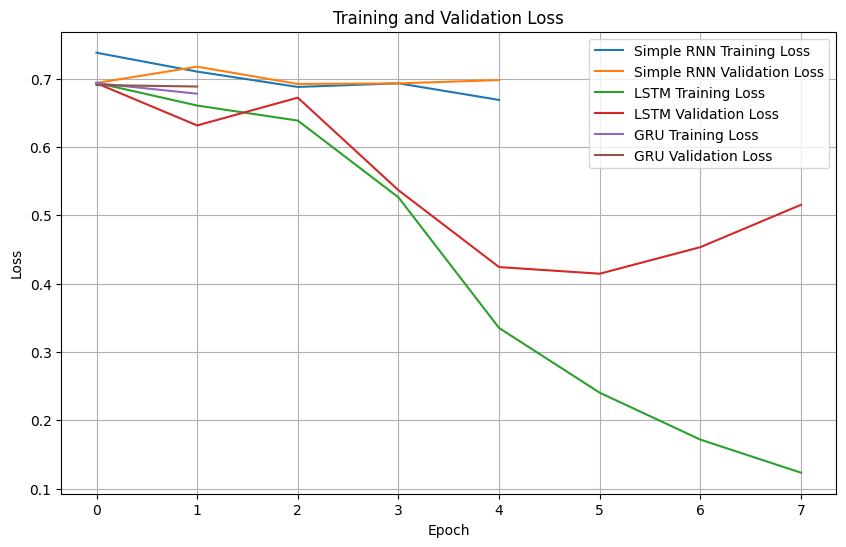

In [25]:
plt.figure(figsize=(10, 6))

plt.plot(
    rnn_history.history["loss"],
    label="Simple RNN Training Loss"
)

plt.plot(
    rnn_history.history["val_loss"],
    label="Simple RNN Validation Loss"
)

plt.plot(
    lstm_history.history["loss"],
    label="LSTM Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="LSTM Validation Loss"
)

plt.plot(
    gru_history.history["loss"],
    label="GRU Training Loss"
)

plt.plot(
    gru_history.history["val_loss"],
    label="GRU Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

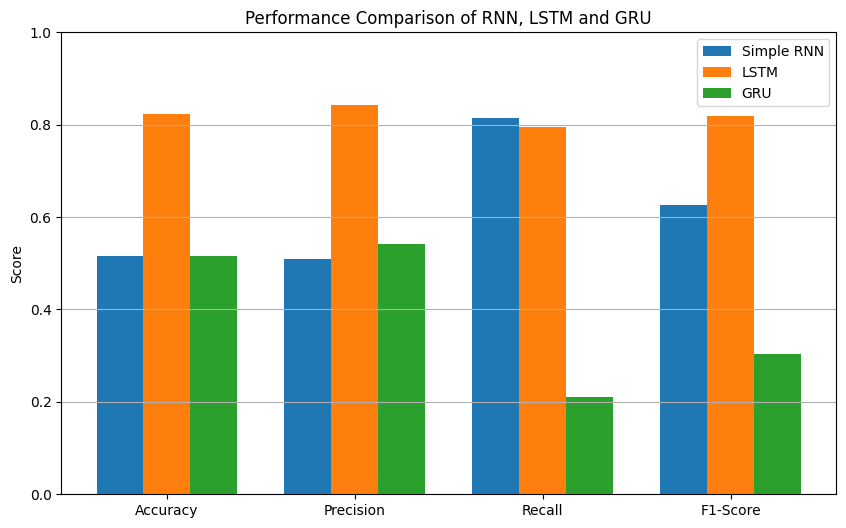

In [26]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    x - width,
    comparison.loc[0, metrics],
    width,
    label="Simple RNN"
)

plt.bar(
    x,
    comparison.loc[1, metrics],
    width,
    label="LSTM"
)

plt.bar(
    x + width,
    comparison.loc[2, metrics],
    width,
    label="GRU"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Performance Comparison of RNN, LSTM and GRU")
plt.legend()
plt.grid(axis="y")

plt.show()

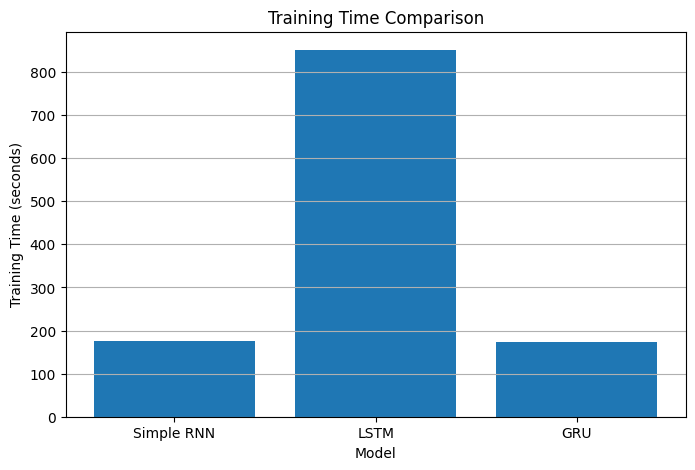

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Training Time (sec)"]
)

plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")
plt.grid(axis="y")

plt.show()

In [28]:
def preprocess_custom_review(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    encoded = [1]

    for word in words:
        if word in word_index:
            index = word_index[word] + 3

            if index < VOCAB_SIZE:
                encoded.append(index)
            else:
                encoded.append(2)
        else:
            encoded.append(2)

    return pad_sequences(
        [encoded],
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )


def predict_sentiment(text):
    processed = preprocess_custom_review(text)

    rnn_prob = rnn_model.predict(processed, verbose=0)[0][0]
    lstm_prob = lstm_model.predict(processed, verbose=0)[0][0]
    gru_prob = gru_model.predict(processed, verbose=0)[0][0]

    print("\nReview:", text)

    print(
        "\nSimple RNN:",
        "Positive" if rnn_prob >= 0.5 else "Negative",
        f"({rnn_prob:.4f})"
    )

    print(
        "LSTM:",
        "Positive" if lstm_prob >= 0.5 else "Negative",
        f"({lstm_prob:.4f})"
    )

    print(
        "GRU:",
        "Positive" if gru_prob >= 0.5 else "Negative",
        f"({gru_prob:.4f})"
    )

In [29]:
predict_sentiment(
    "This movie was absolutely fantastic and I really enjoyed it."
)

predict_sentiment(
    "The movie was boring, poorly written and extremely disappointing."
)


Review: This movie was absolutely fantastic and I really enjoyed it.

Simple RNN: Positive (0.5348)
LSTM: Positive (0.9731)
GRU: Negative (0.4759)

Review: The movie was boring, poorly written and extremely disappointing.

Simple RNN: Positive (0.5348)
LSTM: Negative (0.0496)
GRU: Negative (0.4759)


In [30]:
comparison.to_csv(
    "RNN_LSTM_GRU_Comparison.csv",
    index=False
)

print("Comparison table saved successfully.")

Comparison table saved successfully.
